# Comparing all of the methods we used in order to evaluate the QDs

In [3]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

import data_preprocessing as dp
import detection_algorithms as da
import detection_errors as de

In [4]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"

In [5]:
%%capture
%run "./npy-data-QD-ANALYSIS.ipynb" 

Comparing dot detection within all of the methods

# Preprocessing and uploading the data

**1. Ground truth outputs across the 3 AFM images**

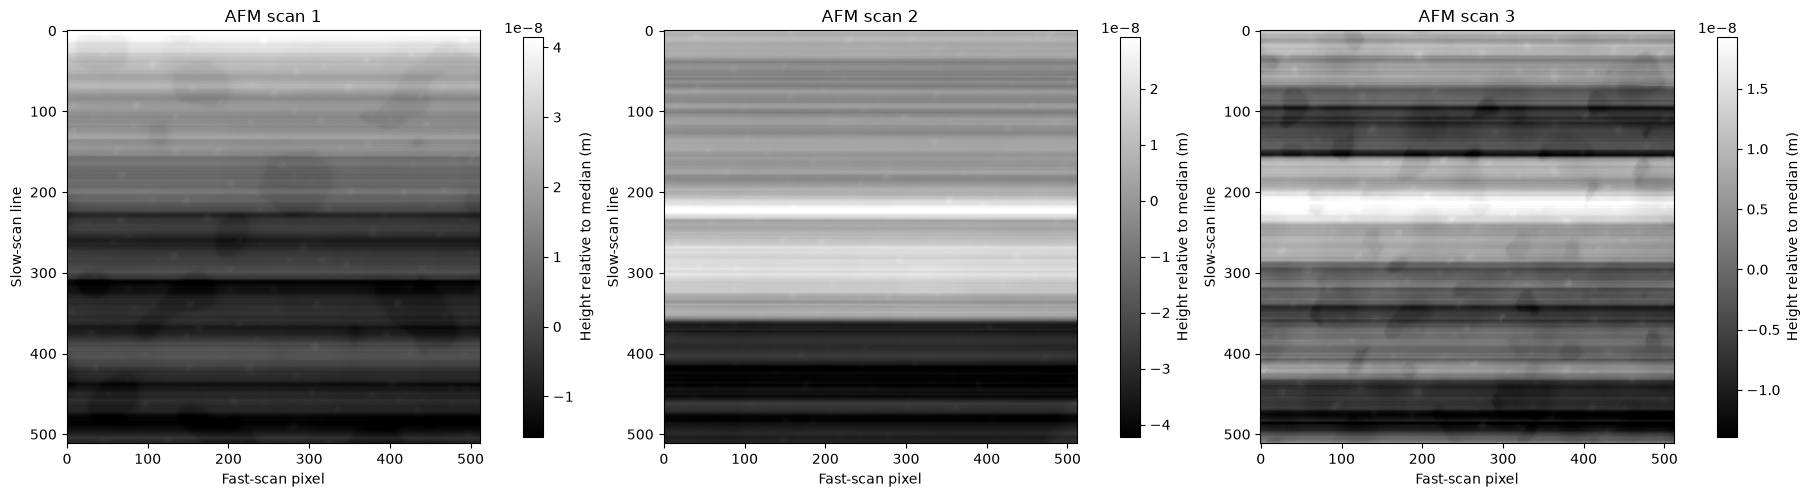

In [18]:
afm_files = [
    Path("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data.npy"),
]

titles = [ "AFM scan 1", "AFM scan 2", "AFM scan 3",]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True,)

for ax, path, title in zip(axes, afm_files, titles):
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    # Centre the height data around zero.
    z_display = z - np.nanmedian(z)

    # Robust display contrast.
    vmin, vmax = np.nanpercentile(z_display, [1, 99],)

    image = ax.imshow(z_display, cmap="gray", vmin=vmin, vmax=vmax, origin="upper",)

    ax.set_title(title)
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

    fig.colorbar(image, ax=ax, label="Height relative to median (m)", shrink=0.85,)

plt.show()

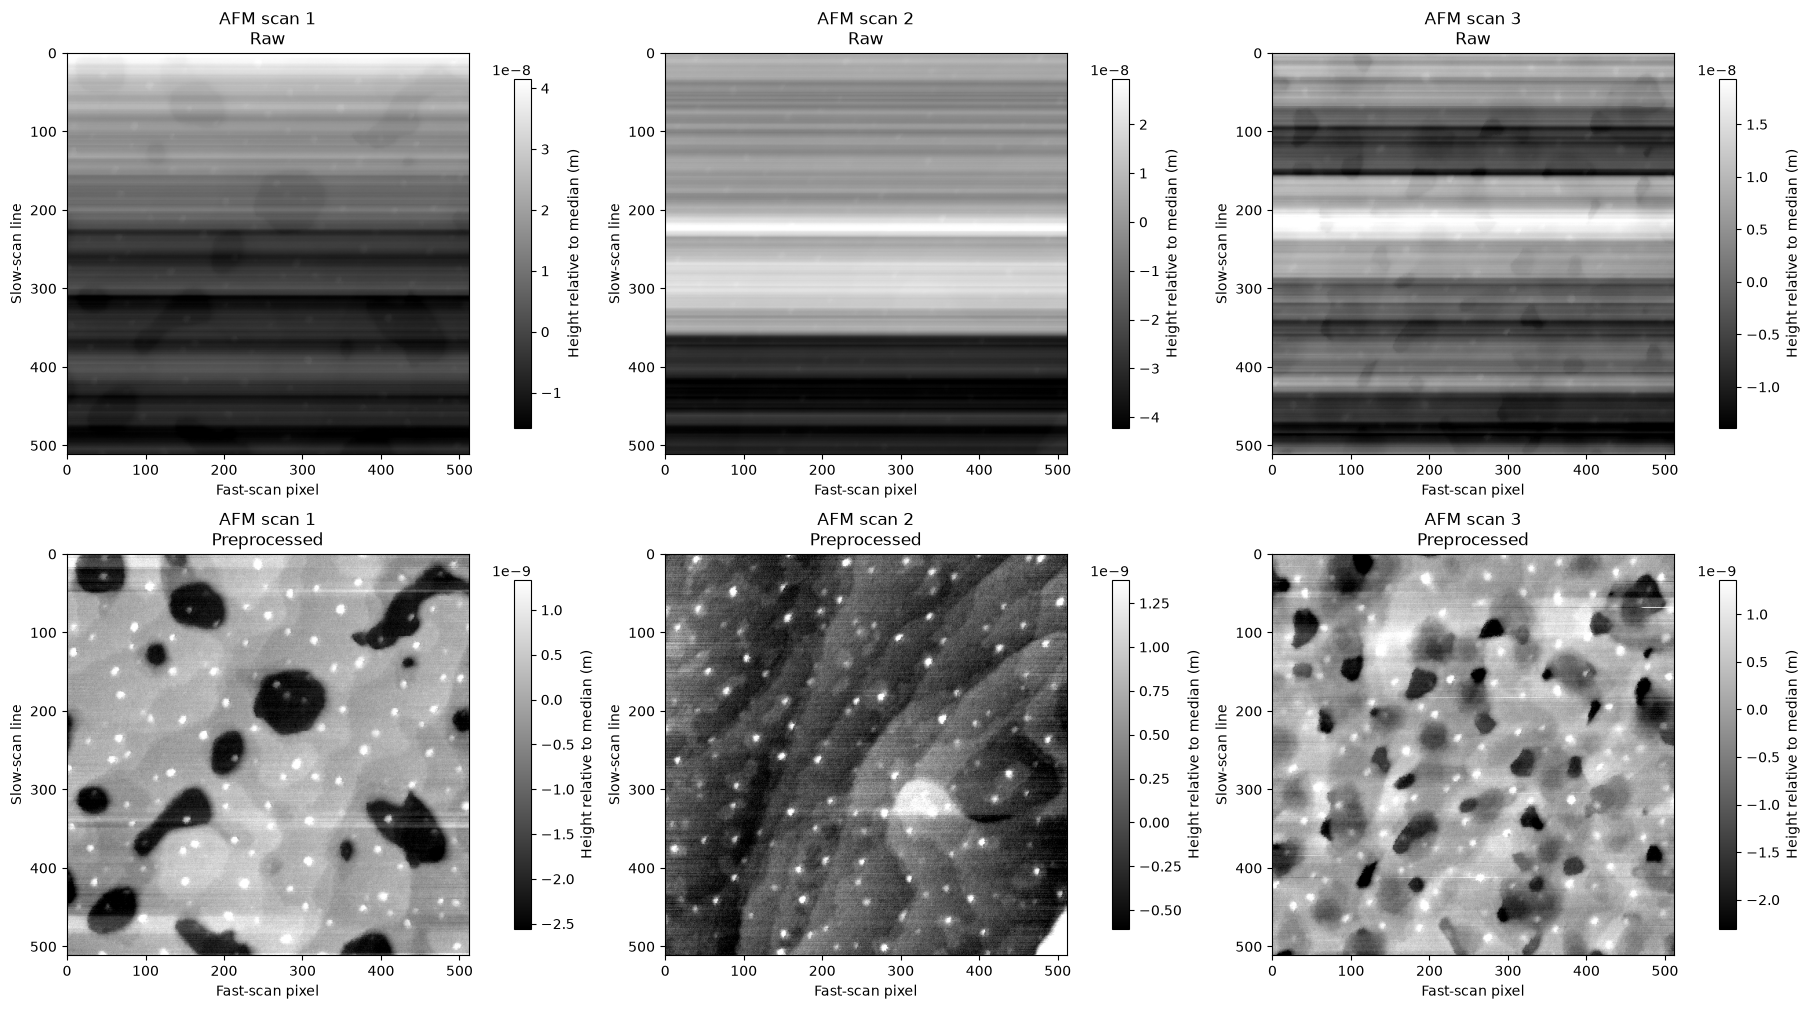

In [19]:
raw_scans = []
processed_scans = []

for path in afm_files:
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    z_processed, stages = dp.preprocess_afm(
        z,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(z)
    processed_scans.append(z_processed)


fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for column, (raw, processed, title) in enumerate(
    zip(raw_scans, processed_scans, titles)):
    
    raw_display = raw - np.nanmedian(raw)
    raw_vmin, raw_vmax = np.nanpercentile(raw_display, [1, 99],)

    raw_image = axes[0, column].imshow(
        raw_display,
        cmap="gray",
        vmin=raw_vmin,
        vmax=raw_vmax,
        origin="upper",
    )

    axes[0, column].set_title(f"{title}\nRaw")
    axes[0, column].set_xlabel("Fast-scan pixel")
    axes[0, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        raw_image,
        ax=axes[0, column],
        label="Height relative to median (m)",
        shrink=0.85,
    )

    processed_vmin, processed_vmax = np.nanpercentile(processed, [1, 99],)

    processed_image = axes[1, column].imshow(
        processed,
        cmap="gray",
        vmin=processed_vmin,
        vmax=processed_vmax,
        origin="upper",
    )

    axes[1, column].set_title(f"{title}\nPreprocessed")
    axes[1, column].set_xlabel("Fast-scan pixel")
    axes[1, column].set_ylabel("Slow-scan line")

    fig.colorbar(
        processed_image,
        ax=axes[1, column], 
        label="Height relative to median (m)",
        shrink=0.85,
    )

plt.show()

# Ground Truth Blobs Labelled

Taken from Chenuye's Dataset

### Ground-truth scan images

<p align="center">
  <img src="Ground-Truth/Images/AIX6461_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6468_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
  <img src="Ground-Truth/Images/AIX6470_centre_500nm_200pN_18 gain.0_00000_1.spm.jpg" width="31%">
</p>

### Labelled Ground-truth set

<p align="center">
  <img src="Ground-Truth/Images/LabelledQDs.png" width="100%">
</p>

In [20]:
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from skimage.measure import label, regionprops

import data_preprocessing as dp

1. Convert a mask into QD centres 

In [21]:
def centres_from_binary_mask(binary_mask):
    binary_mask = np.asarray(binary_mask, dtype=bool)

    labelled_mask = label(binary_mask, connectivity=2,)

    centres = [region.centroid for region in regionprops(labelled_mask)]

    if not centres:
        return np.empty((0, 2), dtype=float)

    return np.asarray(centres, dtype=float)

dataset = {}
ground_truth_masks = [
    np.load("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data_mask.npy"),
]

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    ground_truth_centres = centres_from_binary_mask(mask)

    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": ground_truth_centres,
    }

    print(
        scan_name,
        "ground-truth QDs:",
        len(ground_truth_centres),
    )

Scan1 ground-truth QDs: 133
Scan2 ground-truth QDs: 137
Scan3 ground-truth QDs: 135


## 0. Analysing the data using QD detection algorithms 

Calling their functions to check everything is outputted in the same format and works well.

**Striped, no smoothing** <br>
use_destriped=False <br>
apply_smoothing=False <br>

**Striped, anisotropic smoothing** <br>
use_destriped=False <br>
apply_smoothing=True <br>

**Destriped, no smoothing** <br>
use_destriped=True <br>
apply_smoothing=False <br>

**Destriped, anisotropic smoothing** <br>
use_destriped=True <br>
apply_smoothing=True <br>

0.1 Laplacian of Gaussian

In [22]:
log_results = da.log_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    gaussian_sigma=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.2 Chambolle anisotropic diffusion smoothing instead of Gaussian smoothing used in the above function

In [23]:
cad_results = da.chambolle_anisotropic_diffusion_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    diffusion_weight=0.08,
    max_num_iter=200,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.3 QD detection via Otsu threshold being used in LoG

In [24]:
otsu_results = da.otsu_detect(
    z,
    z_processed,
    destriped=True,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    overlap=0.5,
    minimum_height=6e-10,
)

0.4 Hough Transform Detection 

In [25]:
ht_results = da.hough_transform_detect(
    z,
    z_processed,
    destriped=True,
    canny_sigma=1,
    min_radius=2,
    max_radius=8,
    min_xdistance=5,
    min_ydistance=5,
    threshold_relative=0.73,
    normalize=True,
    minimum_height=6e-10,
)

0.5 Perona Maulik anisotropic diffusion 

In [26]:
pmab_results = da.peronamalik_anisotropic_diffusion_detect(
    z,
    z_processed,
    destriped=True,
    smoothing=True,
    low_sigma=5,
    high_sigma=40,
    n_iterations=15,
    kappa=0.4,
    gamma=0.15,
    option=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.6 Phase congruency/ phase symmetry 

In [27]:
pc_results = da.detect_qds_phase_symmetry(
    z,
    z_processed,
    destriped=True,
    nscale=6,
    min_wavelength=1.5,
    mult=9.0,
    noise_k=2.5,
    symmetry_threshold=0.08,
    min_distance=3,
    minimum_height=6e-10,
)

0.7 SIFT detection 

In [28]:
sift_results = da.sift_detect(
    z,
    z_processed,
    destriped=True,
    background_sigma=10,
    qd_min_sigma=0.8,
    qd_max_sigma=4.0,
    upsampling=2,
    n_octaves=3,
    n_scales=5,
    sigma_min=2,
    sigma_in=0.5,
    c_dog=0.05,
    c_edge=15,
    lower_percentile=1,
    upper_percentile=99,
    minimum_height=6e-10,
)

0.8 Using geometric contours for QD detection 

In [29]:
da.geometric_contour_detect(
    z,
    z_processed,
    striped_centres=log_centres,
    destriped_centres=log_centres,
    destriped=True,
    minimum_height=6e-10,
)

NameError: name 'log_centres' is not defined

0.9 Using Chan-Vese contur detection 

In [30]:
da.chan_vese_detect(
    z,
    z_processed,
    300, # striped centres 
    250, # destriped centres 
    destriped=True,
    initial_radius=3,
    num_iter=80,
    smoothing=1,
    lambda1=1,
    lambda2=2,
    min_area=1,
    minimum_height=6e-10,
)

ValueError: cannot reshape array of size 1 into shape (2)

0.10 Watershed detection 

In [31]:
ws_results = da.watershed_detect(
    z,
    z_processed,
    destriped=True,
    footprint_radius=6,
    min_size=1,
    min_distance=3,
    min_area=5,
    minimum_height=6e-10,
)

/Users/polinabobrova/Desktop/GaN Quantum Dot Analysis/detection_algorithms.py:702: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  qd_mask = remove_small_objects(processed_image > threshold, min_size=min_size)


0.11 Using Gabor wavelets for QD detection -> this takes longest to execute by time 

In [32]:
gw_results = da.gabor_detect(
    z,
    z_processed,
    destriped=True,
    smoothing_sigma=0.58,
    top_hat_radius=6,
    wavelengths=(2, 3, 4, 5, 6, 8),
    number_of_orientations=8,
    bandwidth=1.0,
    threshold_percentile=90,
    min_distance=2,
    minimum_height=6e-10,
)

## 2. Object-level detection metrics 

This will help identifying if the algorithms managed to find the correct dots - this compares predicted and real centres 

In [33]:
algorithm_results = {
    "LoG": log_results,
    "CAD": cad_results,
    "Otsu": otsu_results,
    "HT": ht_results,
    "PMAD": pmab_results,
    "PC": pc_results,
    "SIFT": sift_results,
    "WS": ws_results,
    "GW": gw_results,
}

## 3. Error table

In [34]:
rows = []

true_centres = dataset["Scan3"]["ground_truth_centres"]

true_result = {
    "mask": dataset["Scan3"]["ground_truth_mask"],
    "centres": true_centres,
    "heights": np.full(len(true_centres), np.nan),
    "radii": np.full(len(true_centres), np.nan),
    "areas": np.full(len(true_centres), np.nan),
}


for algorithm_name, result in algorithm_results.items():
    rows.append(
        da.make_results_row(
            algorithm_name=algorithm_name,
            stage_name="Before height filter",
            predicted_result=result["before_height_filter"],
            true_result=true_result,
        )
    )

    rows.append(
        da.make_results_row(
            algorithm_name=algorithm_name,
            stage_name="After height filter",
            predicted_result=result["after_height_filter"],
            true_result=true_result,
        )
    )

results_table = pd.DataFrame(rows)
results_table = results_table.round(4)

display(results_table)

,Algorithm,Stage,Predicted count,True count,Count error,Absolute count error,Pixel precision,Pixel recall,Pixel F1,Dice,...,Localisation mean (px),Localisation median (px),Localisation RMSE (px),Localisation maximum (px),Height MAE,Height RMSE,Radius MAE,Radius RMSE,Area MAE,Area RMSE
0,LoG,Before height filter,232,135,97,97,0.2037,0.7590,0.3212,0.3212,...,1.8139,1.5660,2.1762,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,LoG,After height filter,138,135,3,3,0.3761,0.6897,0.4867,0.4867,...,1.6893,1.4250,2.0341,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
2,CAD,Before height filter,253,135,118,118,0.1990,0.7435,0.3139,0.3139,...,1.8254,1.5834,2.1839,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
3,CAD,After height filter,141,135,6,6,0.3803,0.6711,0.4855,0.4855,...,1.6938,1.4120,2.0403,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
4,Otsu,Before height filter,322,135,187,187,0.1737,0.7528,0.2823,0.2823,...,1.8057,1.5660,2.1647,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
5,Otsu,After height filter,154,135,19,19,0.3707,0.6722,0.4779,0.4779,...,1.7138,1.4250,2.0468,5.0000,NaN,NaN,NaN,NaN,NaN,NaN
6,HT,Before height filter,491,135,356,356,0.1317,0.0711,0.0924,0.0924,...,1.8747,1.8679,2.1480,4.3791,NaN,NaN,NaN,NaN,NaN,NaN
7,HT,After height filter,28,135,-107,107,0.9026,0.0662,0.1233,0.1233,...,1.7720,1.5965,2.0484,4.3791,NaN,NaN,NaN,NaN,NaN,NaN
8,PMAD,Before height filter,117,135,-18,18,0.1466,0.5985,0.2355,0.2355,...,1.8272,1.7096,2.0613,4.3904,NaN,NaN,NaN,NaN,NaN,NaN
9,PMAD,After height filter,73,135,-62,62,0.2025,0.5253,0.2923,0.2923,...,1.8568,1.7096,2.0847,4.3904,NaN,NaN,NaN,NaN,NaN,NaN


**Then, I decided to overlay the binary masks:**

1. ground truth = green transparent
2. prediction = magenta transparent

In [58]:
import math

def plot_detection_overlays_filled(
    algorithm_results,
    true_result,
    base_image,
    stage_key="after_height_filter",
    cmap="grey",
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 5 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    base_image = np.asarray(base_image, dtype=float)
    true_mask = np.asarray(true_result["mask"], dtype=bool)

    for ax, algorithm_name in zip(axes, algorithm_names):
        result = algorithm_results[algorithm_name]
        predicted = result[stage_key]
        predicted_mask = np.asarray(predicted["mask"], dtype=bool)

        ax.imshow(base_image, cmap=cmap, origin="upper")

        # Ground truth overlay: green
        true_overlay = np.zeros((*true_mask.shape, 4), dtype=float)
        true_overlay[..., 1] = 1.0
        true_overlay[..., 3] = 0.28 * true_mask
        ax.imshow(true_overlay, origin="upper")

        # Predicted overlay: magenta
        pred_overlay = np.zeros((*predicted_mask.shape, 4), dtype=float)
        pred_overlay[..., 0] = 1.0
        pred_overlay[..., 2] = 1.0
        pred_overlay[..., 3] = 0.28 * predicted_mask
        ax.imshow(pred_overlay, origin="upper")

        ax.set_title(
            f"{algorithm_name}\n"
            f"GT: {len(true_result['centres'])} | Pred: {len(predicted['centres'])}"
        )
        ax.set_xlabel("x pixel")
        ax.set_ylabel("y pixel")

    for ax in axes[n_methods:]:
        ax.axis("off")

    fig.suptitle(
        f"Filled detection overlays — {stage_key.replace('_', ' ').title()}\n"
        f"Green = Ground truth, Magenta = Prediction",
        fontsize=14,
    )

    plt.show()

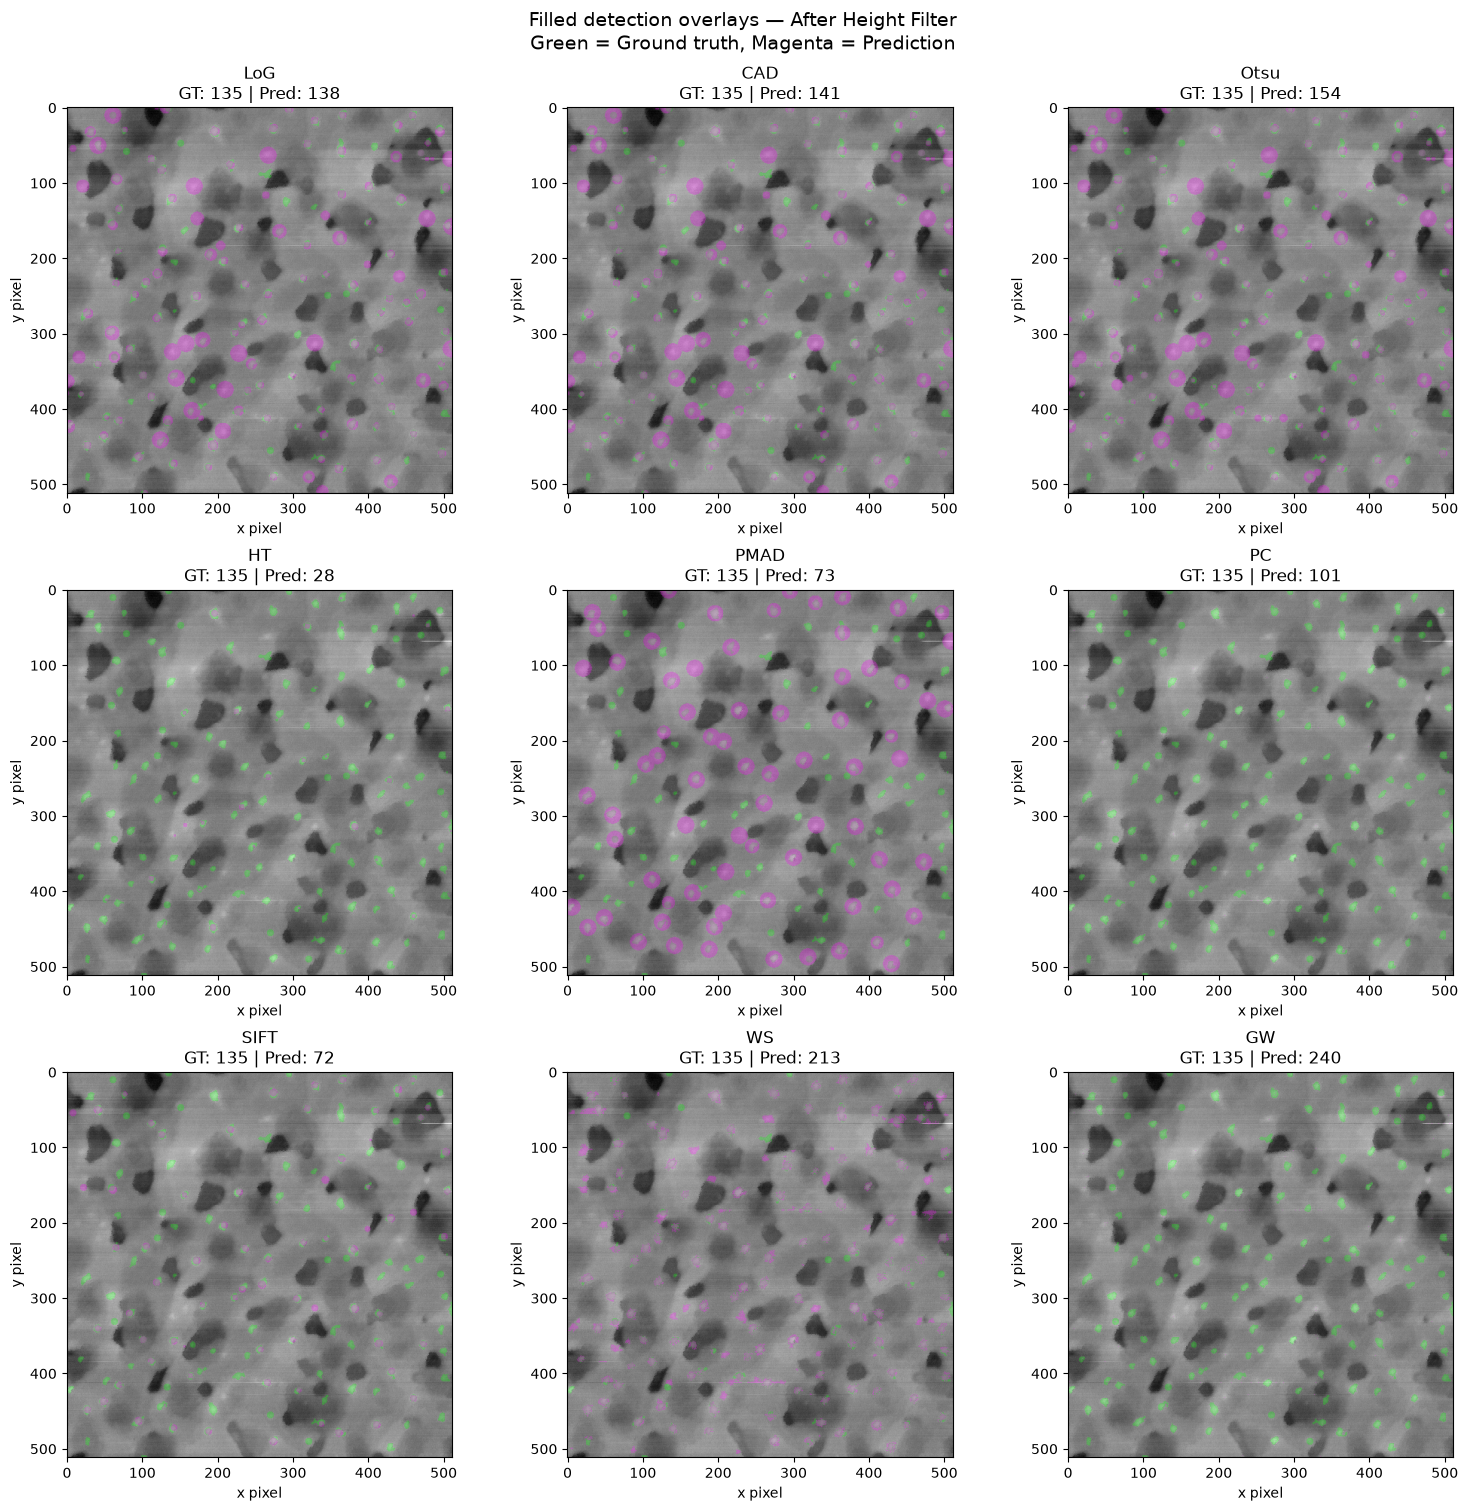

In [59]:
plot_detection_overlays_filled(
    algorithm_results=algorithm_results,
    true_result=true_result,
    base_image=dataset["Scan3"]["processed"],
    stage_key="after_height_filter",
)

In [37]:
def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def plot_parameter_histograms(
    algorithm_results,
    true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius (px)",
    bins=20,
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    true_values = finite_values(true_result[parameter_key])

    for ax, algorithm_name in zip(axes, algorithm_names):
        predicted_result = algorithm_results[algorithm_name][stage_key]
        predicted_values = finite_values(predicted_result[parameter_key])

        if len(true_values) > 0:
            ax.hist(
                true_values,
                bins=bins,
                alpha=0.5,
                density=False,
                label="Ground truth",
            )

        if len(predicted_values) > 0:
            ax.hist(
                predicted_values,
                bins=bins,
                alpha=0.5,
                density=False,
                label=algorithm_name,
            )

        ax.set_title(f"{algorithm_name} — {stage_key.replace('_', ' ')}")
        ax.set_xlabel(parameter_label)
        ax.set_ylabel("Frequency")
        ax.legend()

    for ax in axes[n_methods:]:
        ax.axis("off")

    plt.show()

radius errors

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_915/2704427778.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


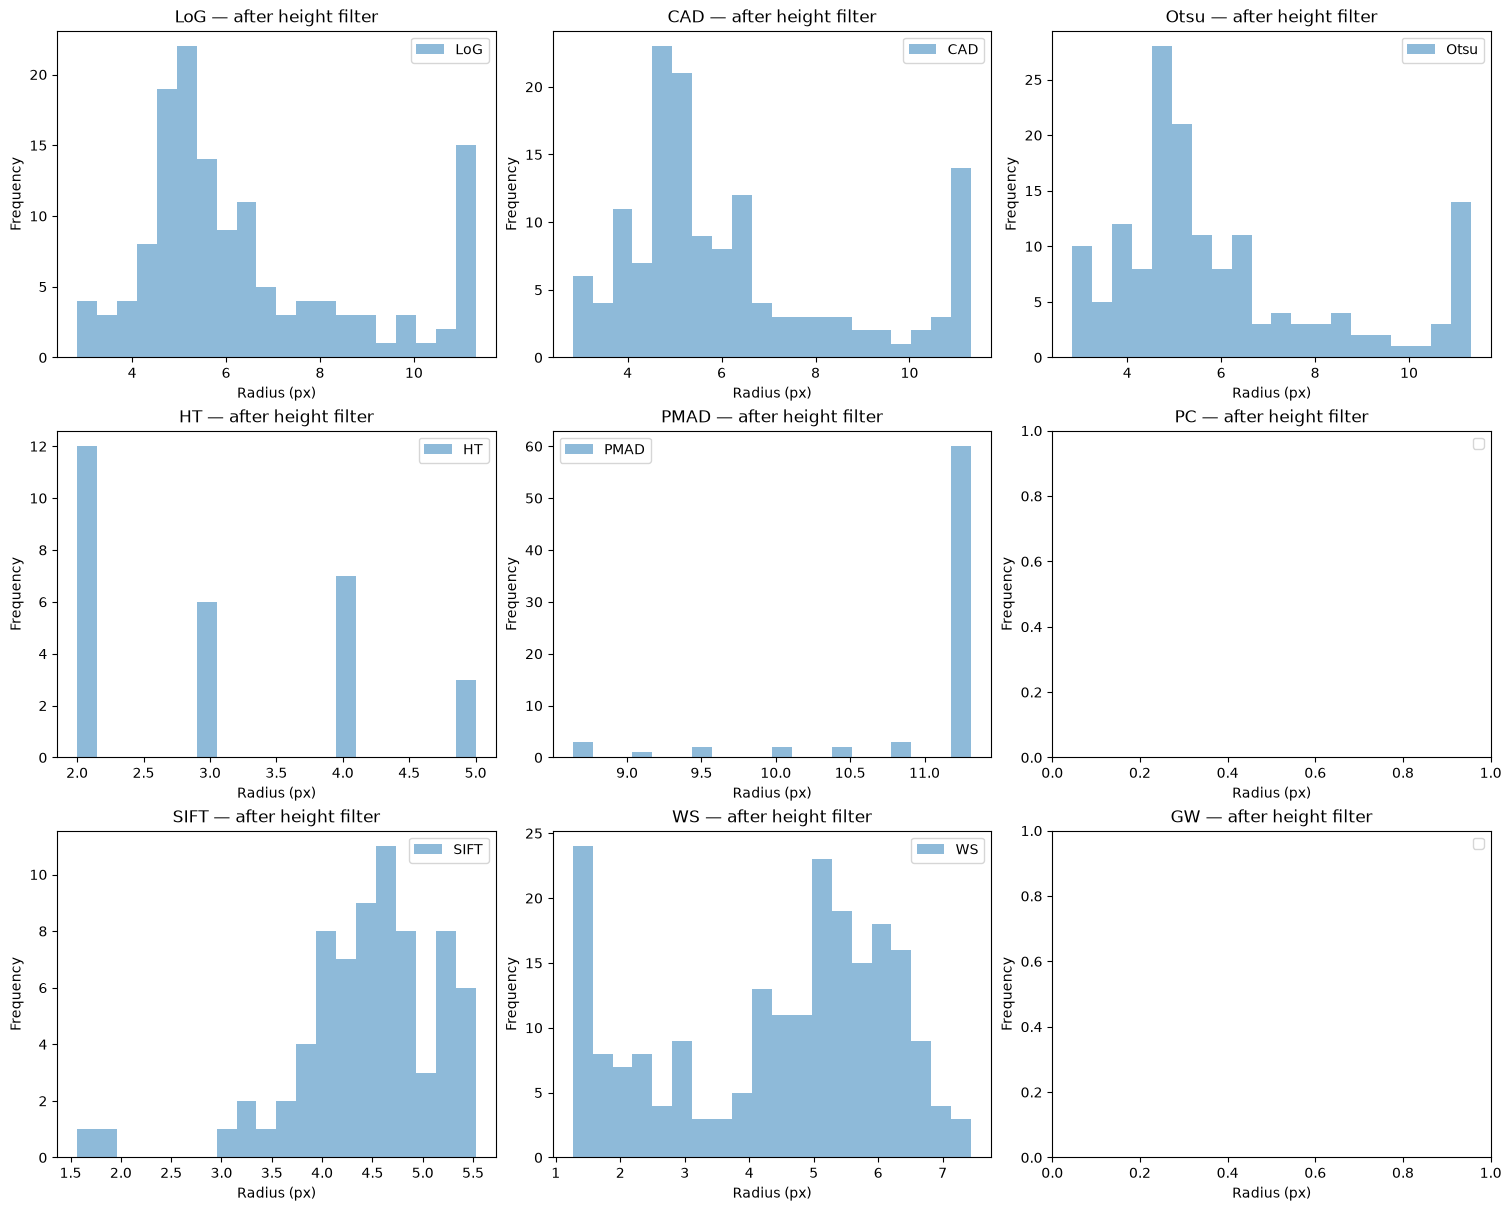

In [38]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius (px)",
    bins=20,
)

area errors

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_915/2704427778.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


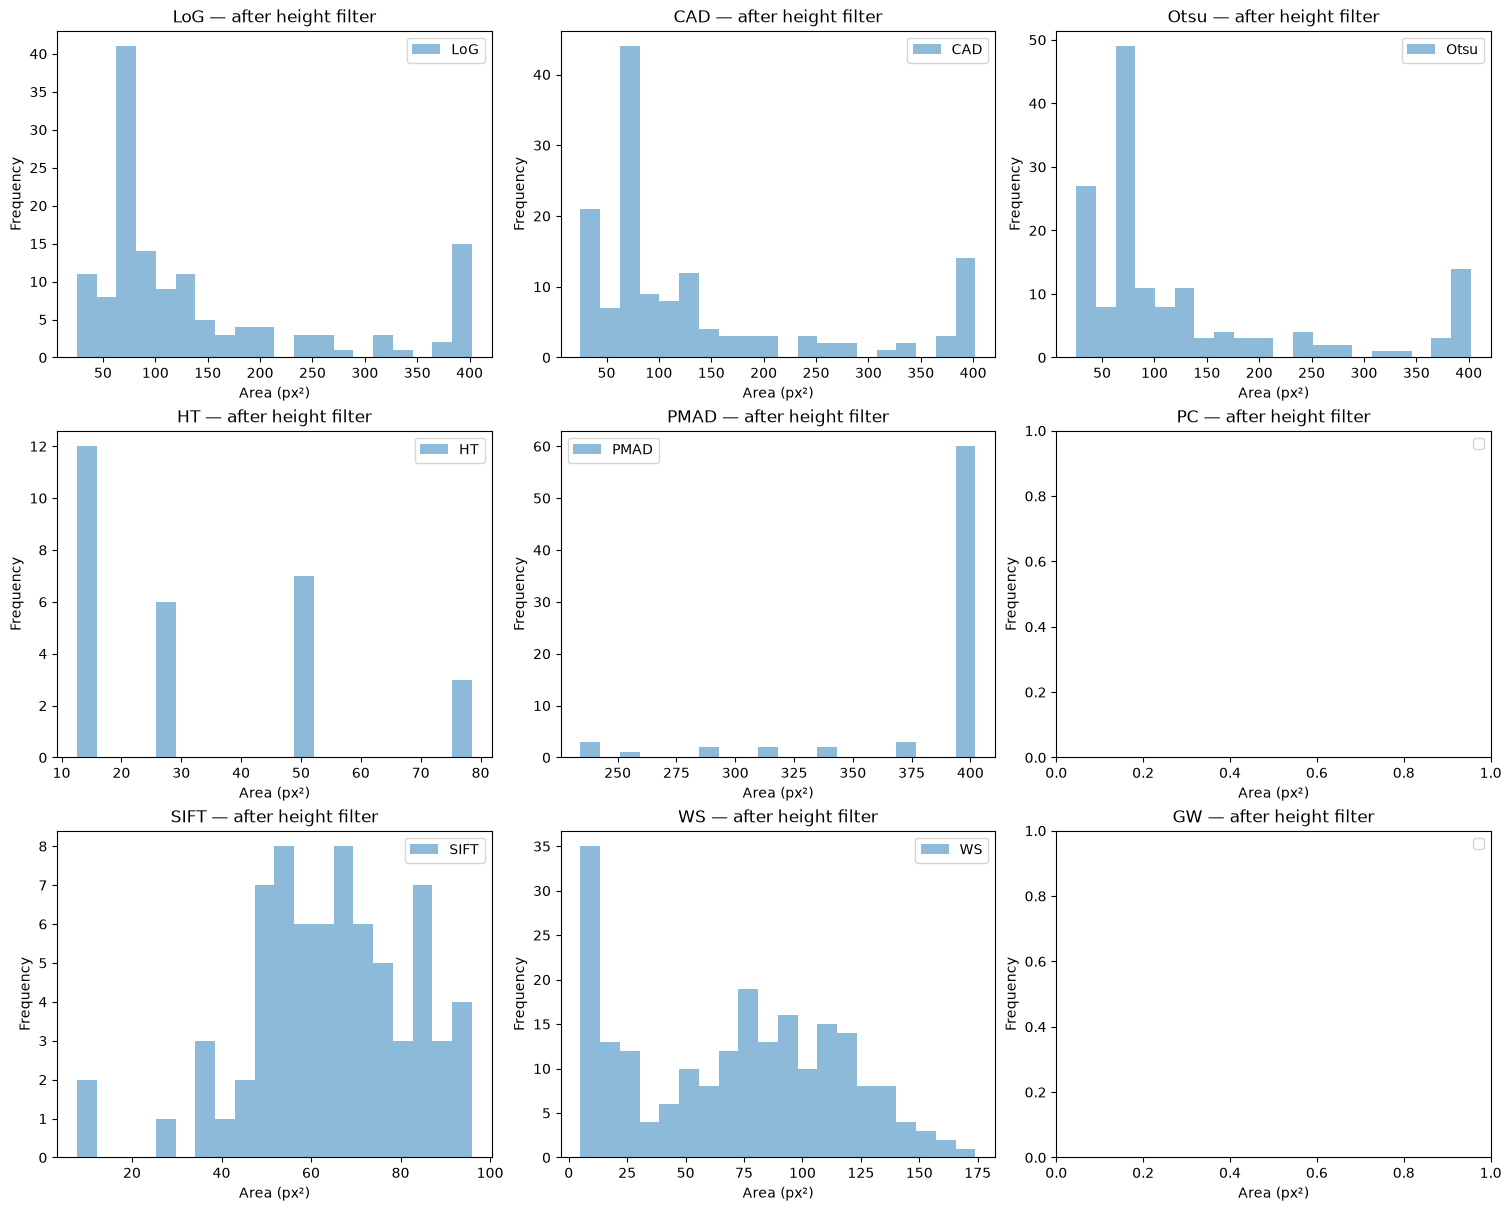

In [40]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="areas",
    parameter_label="Area (px²)",
    bins=20,
)

heights

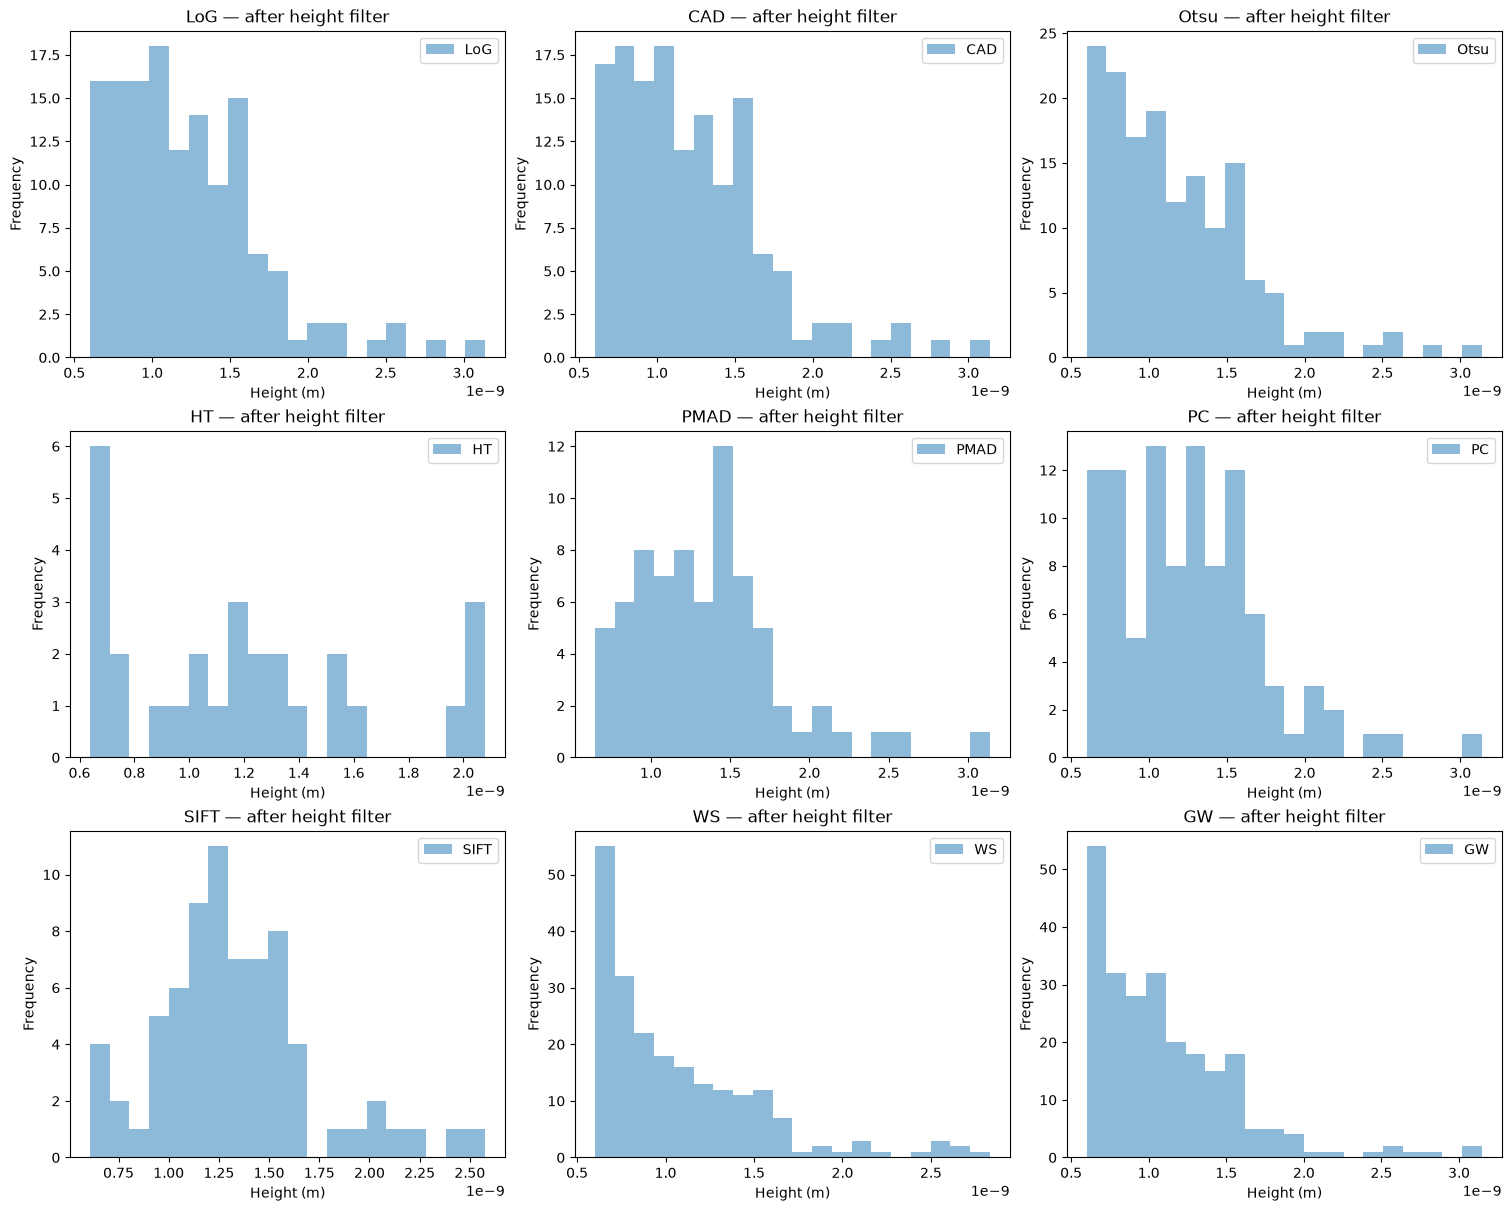

In [41]:
plot_parameter_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="heights",
    parameter_label="Height (m)",
    bins=20,
)

Histogram of matched errors:

In [51]:
from skimage.measure import label, regionprops
import numpy as np


def ground_truth_parameters_from_mask(binary_mask):
    labelled_mask = label(
        np.asarray(binary_mask, dtype=bool),
        connectivity=2,
    )

    regions = regionprops(labelled_mask)

    centres = np.asarray(
        [region.centroid for region in regions],
        dtype=float,
    ).reshape(-1, 2)

    areas = np.asarray(
        [region.area for region in regions],
        dtype=float,
    )

    radii = np.sqrt(areas / np.pi)

    return centres, radii, areas

In [52]:
gt_centres, gt_radii, gt_areas = ground_truth_parameters_from_mask(
    dataset["Scan3"]["ground_truth_mask"]
)

In [53]:
true_result = {
    "mask": dataset["Scan3"]["ground_truth_mask"],
    "centres": gt_centres,
    "heights": np.full(len(gt_centres), np.nan),
    "radii": gt_radii,
    "areas": gt_areas,
}

In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_parameter_error_histograms(
    algorithm_results,
    true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius error (px)",
    bins=20,
    max_distance=5,
):
    algorithm_names = list(algorithm_results.keys())
    n_methods = len(algorithm_names)

    ncols = 3
    nrows = math.ceil(n_methods / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, algorithm_name in zip(axes, algorithm_names):
        predicted_result = algorithm_results[algorithm_name][stage_key]

        matches = de.match_qds(
            predicted_result["centres"],
            true_result["centres"],
            max_distance=max_distance,
        )

        predicted_indices = matches["predicted_indices"]
        true_indices = matches["true_indices"]

        predicted_values = np.asarray(predicted_result[parameter_key], dtype=float)
        true_values = np.asarray(true_result[parameter_key], dtype=float)

        errors = predicted_values[predicted_indices] - true_values[true_indices]
        errors = errors[np.isfinite(errors)]

        if len(errors) > 0:
            ax.hist(
                errors,
                bins=bins,
                alpha=0.7,
            )
            ax.axvline(0, linestyle="--")
            ax.set_title(
                f"{algorithm_name}\n"
                f"mean error = {np.mean(errors):.4g}, n = {len(errors)}"
            )
        else:
            ax.set_title(f"{algorithm_name}\nNo valid matched errors")

        ax.set_xlabel(parameter_label)
        ax.set_ylabel("Frequency")

    for ax in axes[n_methods:]:
        ax.axis("off")

    plt.show()

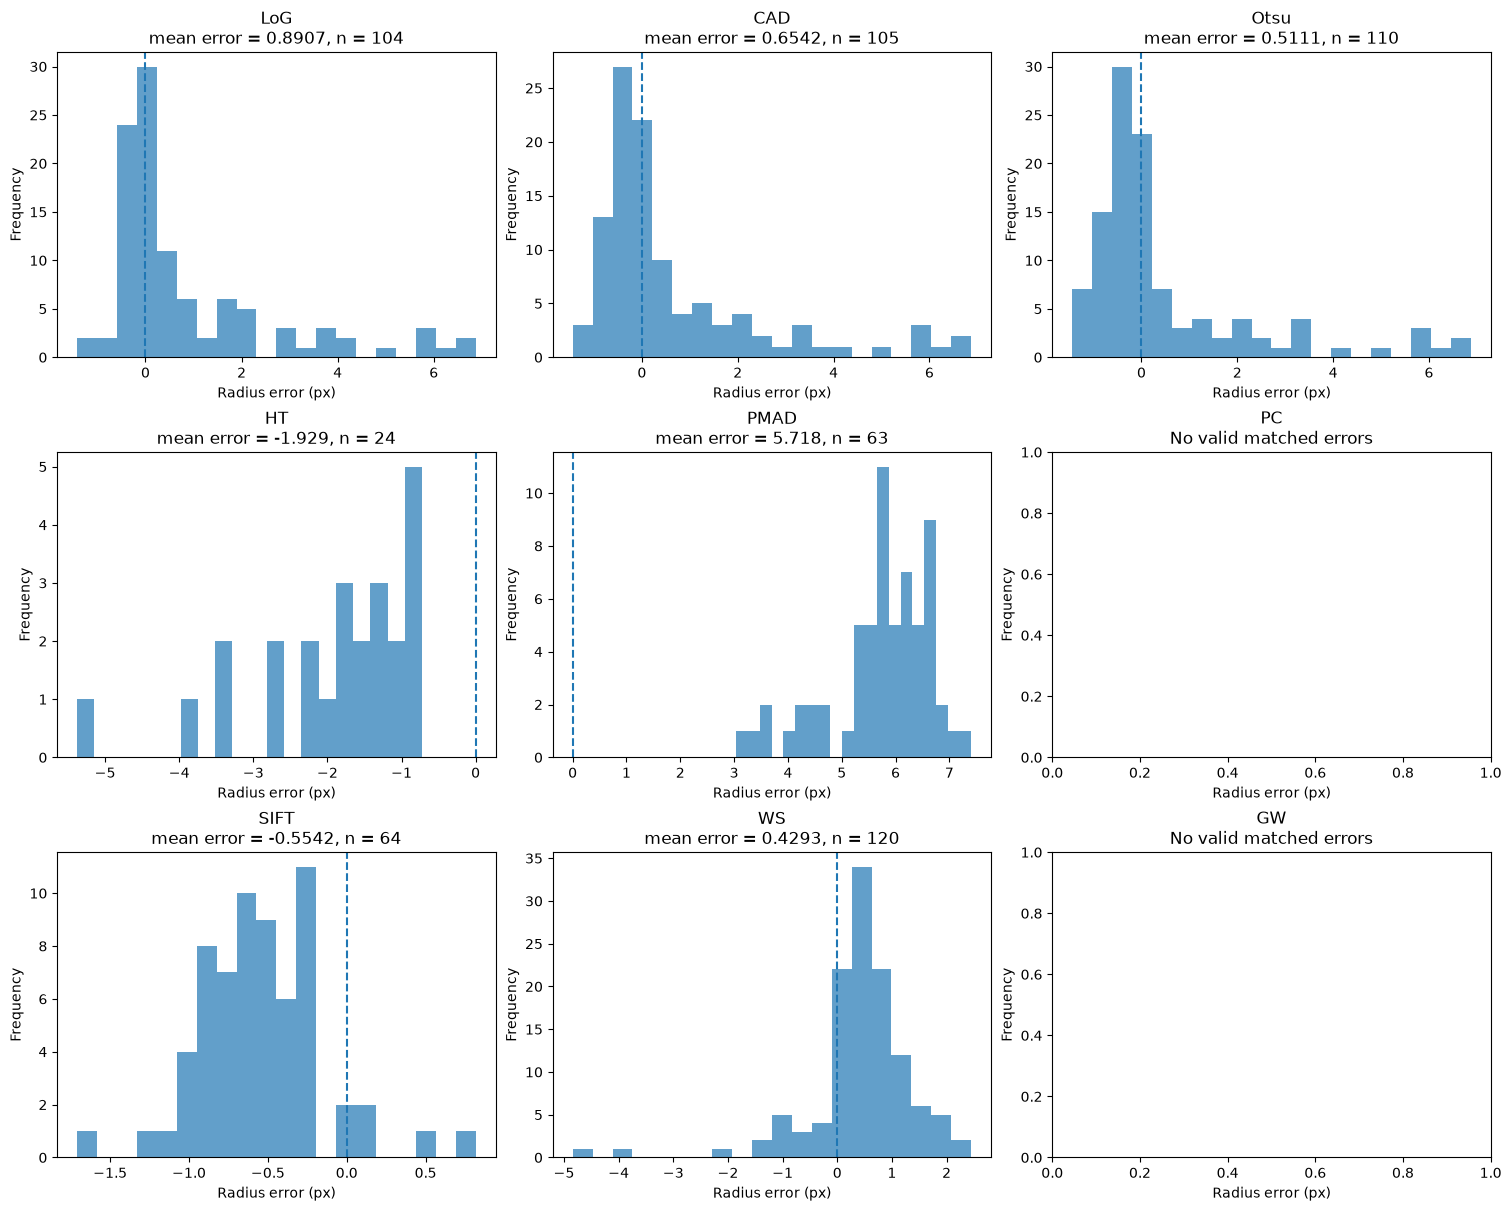

In [55]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="radii",
    parameter_label="Radius error (px)",
    bins=20,
    max_distance=5,
)

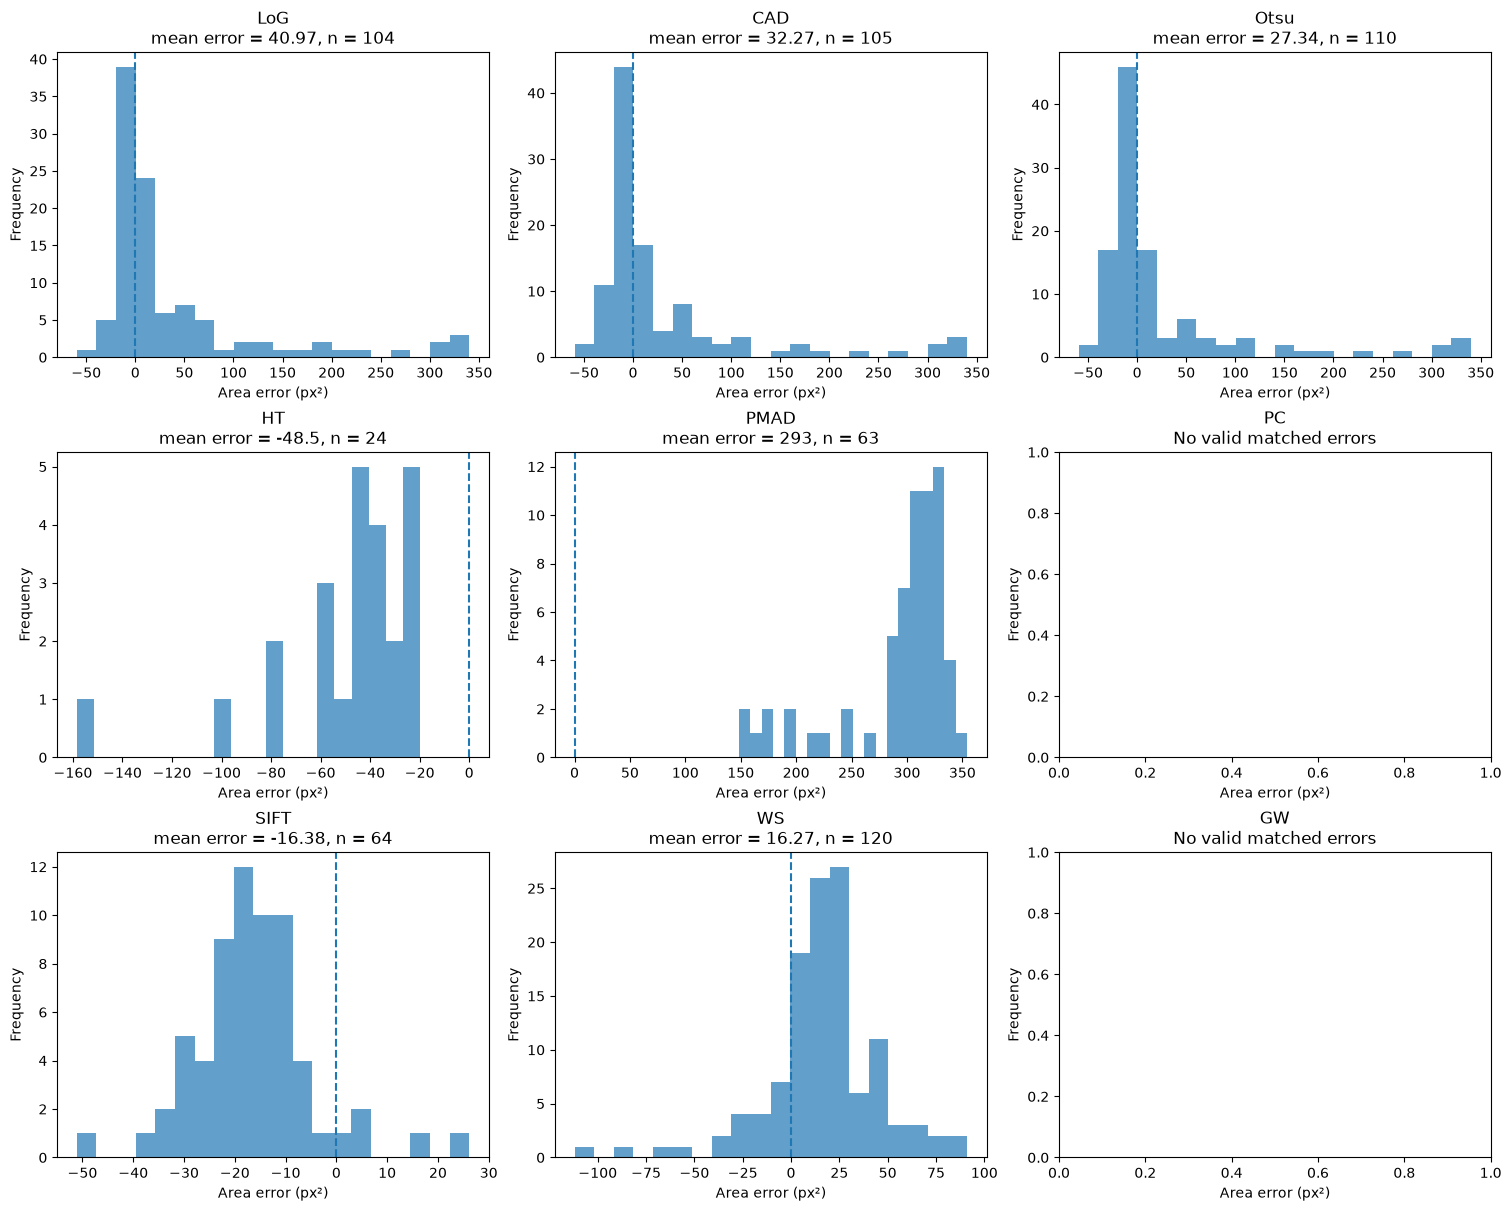

In [56]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="areas",
    parameter_label="Area error (px²)",
    bins=20,
    max_distance=5,
)

height error

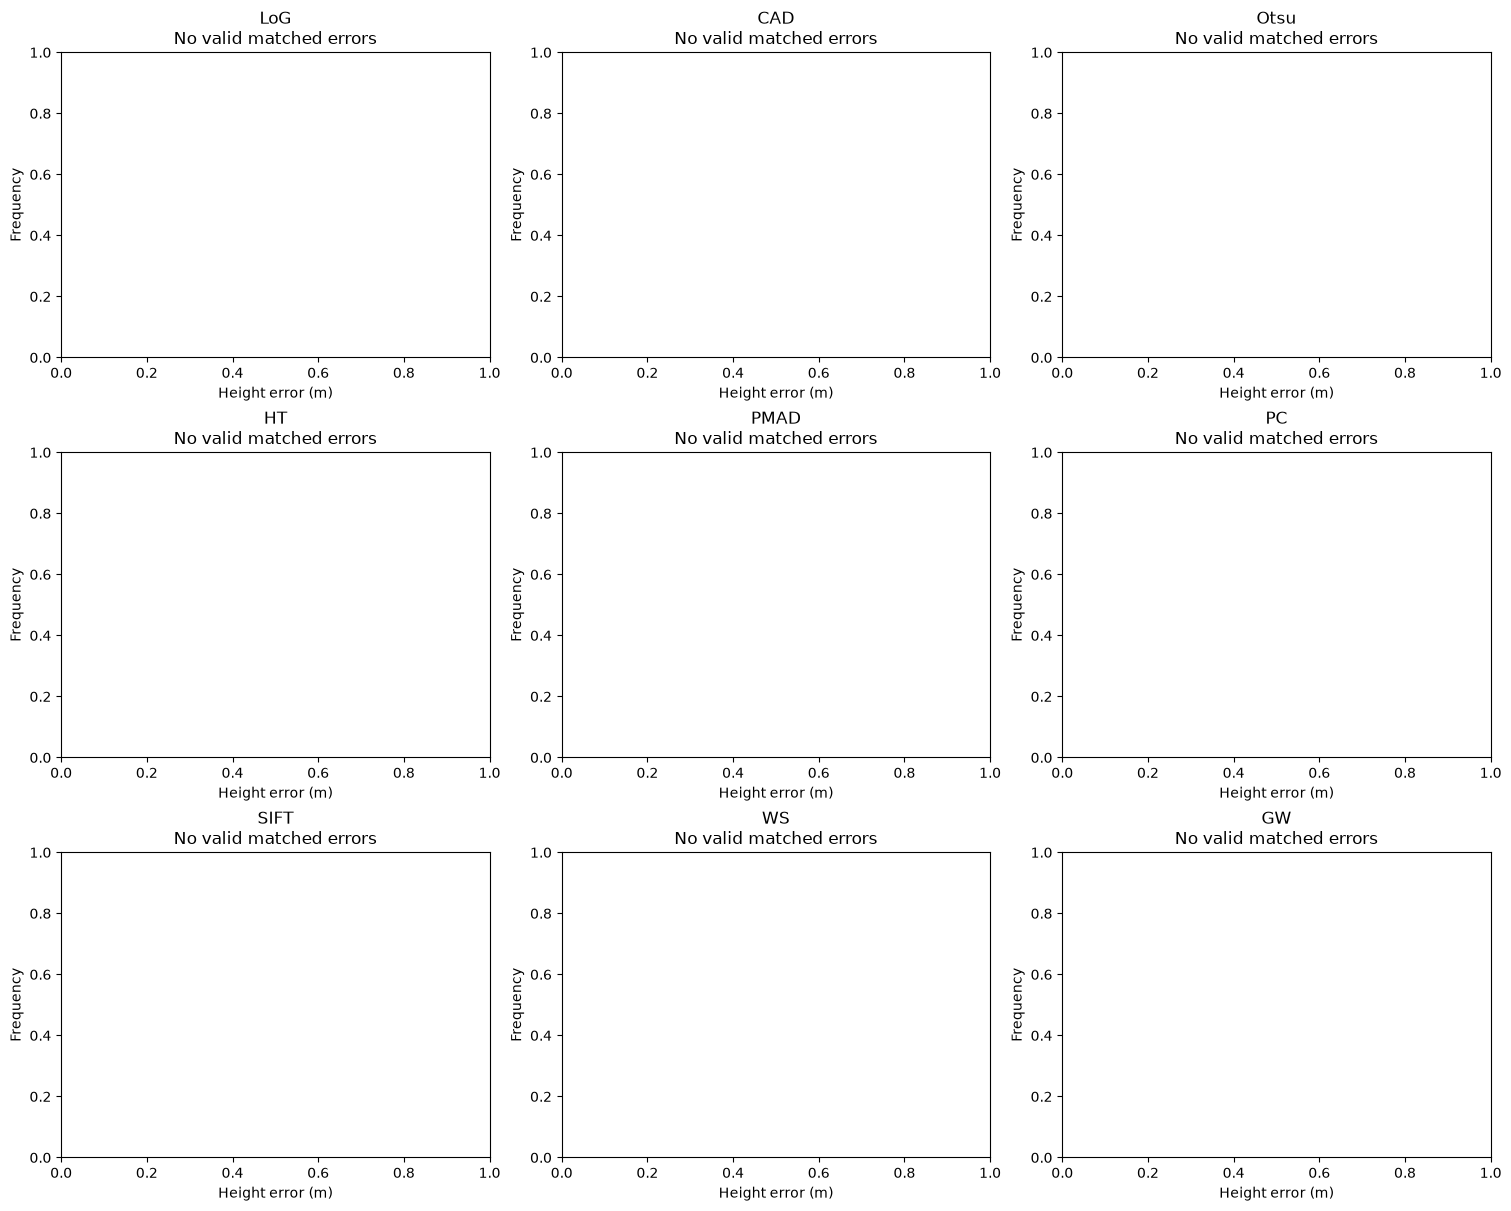

In [57]:
plot_parameter_error_histograms(
    algorithm_results=algorithm_results,
    true_result=true_result,
    stage_key="after_height_filter",
    parameter_key="heights",
    parameter_label="Height error (m)",
    bins=20,
    max_distance=5,
)